# Wide-Screen Prompt Compression Experiment on LongBench

This notebook implements a lightweight demo of the experiment from `method.py`. It compares several prompt compression methods at small scale and prints summary metrics.

**What this artifact does**
- Loads `mini_demo_data.json` from GitHub or local fallback.
- Runs a tiny inference loop with minimal config values.
- Aggregates F1/ROUGE-L metrics and prints a readable summary.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Non-Colab-only packages first
_pip('loguru', 'rouge-score', 'tqdm')

# Core scientific stack: pre-installed on Colab, install locally at Colab's exact versions
if 'google.colab' not in sys.modules:
    _pip(
        'numpy==2.0.2',
        'pandas==2.2.2',
        'scikit-learn==1.6.1',
        'scipy==1.16.3',
        'matplotlib==3.10.0'
    )
    _pip(
        'torch==2.9.0',
        'transformers==5.0.0',
        'tokenizers==0.22.2',
        'huggingface-hub==1.4.0'
    )
_pip('accelerate==1.5.2')


In [2]:
import json
from pathlib import Path
import os
import math
import random
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from rouge_score import rouge_scorer
from loguru import logger
from tqdm import tqdm

# NumPy 2.0 compatibility shims for older dependencies
if not hasattr(np, "alltrue"): np.alltrue = np.all
if not hasattr(np, "sometrue"): np.sometrue = np.any
if not hasattr(np, "product"): np.product = np.prod

# Minimal logging in notebook
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

# Plotting
import matplotlib.pyplot as plt


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-9c6ff9-target-model-guided-prompt-compression/main/round-2/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    local = Path("mini_demo_data.json")
    if local.exists():
        return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")


In [4]:
data = load_data()
examples = []
for dataset in data['datasets']:
    for ex in dataset['examples']:
        examples.append(ex)
print(f"Loaded {len(examples)} examples")


Loaded 2 examples


## Config

Set the smallest values that still produce output. These can be increased later during scaling.

In [5]:
# Tunable parameters — ABSOLUTE MINIMUM values
N_EXAMPLES = min(1, len(examples))
RATIOS = [2.0]
METHODS = ['baseline', 'llmlingua', 'attention_rollout']
BOOTSTRAP_RESAMPLES = 10
SIGNIFICANCE_RESAMPLES = 10
MAX_NEW_TOKENS = 16

# Runtime helpers
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


## Model and metrics setup

Load a small target model and define metric helpers.

In [6]:
MODEL_NAME = "gpt2"

def get_model_max_length(model_name: str) -> int:
    if "llama-3" in model_name.lower() or "meta-llama" in model_name.lower():
        return 8192
    elif "gpt2" in model_name.lower():
        return 1024
    return 2048

def count_tokens(text: str, tokenizer) -> int:
    return len(tokenizer.encode(text, add_special_tokens=False))

def generate_text(model, tokenizer, prompt: str, max_new_tokens: int = MAX_NEW_TOKENS) -> str:
    model_name = getattr(model.config, '_name_or_path', 'unknown')
    max_len = get_model_max_length(model_name)
    max_input_len = max_len - max_new_tokens - 10
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=max_input_len)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

def compute_f1(prediction: str, ground_truth: str) -> float:
    pred_tokens = prediction.lower().split()
    gt_tokens = ground_truth.lower().split()
    if not pred_tokens and not gt_tokens:
        return 1.0
    if not pred_tokens or not gt_tokens:
        return 0.0
    common = set(pred_tokens) & set(gt_tokens)
    if not common:
        return 0.0
    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(gt_tokens)
    return 2 * precision * recall / (precision + recall)

def compute_rouge_l(prediction: str, ground_truth: str) -> float:
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    scores = scorer.score(ground_truth, prediction)
    return scores['rougeL'].fmeasure

def compute_metrics(prediction: str, ground_truth: str, category: str) -> Dict[str, float]:
    f1 = compute_f1(prediction, ground_truth)
    rouge_l = compute_rouge_l(prediction, ground_truth)
    combined = (f1 + rouge_l) / 2.0
    return {"f1": f1, "rouge_l": rouge_l, "combined": combined}

print("Metrics and model helpers defined.")


Metrics and model helpers defined.


## Compression methods

This cell copies the compression method classes from `method.py` with minimal changes.

In [7]:
@dataclass
class CompressionResult:
    method: str
    ratio: float
    example_id: int
    category: str
    task: str
    metrics: Dict[str, float]
    original_tokens: int
    compressed_tokens: int
    compression_info: Dict[str, Any] = field(default_factory=dict)

@dataclass
class AggregatedMetrics:
    method: str
    ratio: float
    category: str
    n_examples: int
    mean_f1: float
    mean_rouge_l: float
    mean_combined: float
    std_f1: float
    std_rouge_l: float
    std_combined: float
    f1_scores: List[float] = field(default_factory=list)
    rouge_l_scores: List[float] = field(default_factory=list)
    combined_scores: List[float] = field(default_factory=list)

class BaseCompressionMethod:
    def __init__(self, name: str):
        self.name = name
    def get_param(self, ratio: float) -> float:
        raise NotImplementedError
    def compress(self, prompt: str, param: float, tokenizer) -> Tuple[str, Dict]:
        raise NotImplementedError

class BaselineMethod(BaseCompressionMethod):
    def __init__(self):
        super().__init__("baseline")
    def get_param(self, ratio: float) -> float:
        return 1.0
    def compress(self, prompt: str, param: float, tokenizer) -> Tuple[str, Dict]:
        tokens = count_tokens(prompt, tokenizer)
        return prompt, {"original_tokens": tokens, "compressed_tokens": tokens, "ratio": 1.0, "compressed_text": prompt}

class LLMLinguaMethod(BaseCompressionMethod):
    def __init__(self, rate_map: Dict[float, float]):
        super().__init__("llmlingua")
        self.rate_map = rate_map
        self._perplexity_model = None
        self._perplexity_tokenizer = None
    def _load_perplexity_model(self):
        if self._perplexity_model is None:
            self._perplexity_tokenizer = AutoTokenizer.from_pretrained("gpt2")
            self._perplexity_model = AutoModelForCausalLM.from_pretrained("gpt2", dtype=torch.float32)
            self._perplexity_model.eval()
            if torch.cuda.is_available():
                self._perplexity_model = self._perplexity_model.cuda()
    def get_param(self, ratio: float) -> float:
        return self.rate_map.get(ratio, 1.0 / ratio)
    def _compute_perplexity_scores(self, text: str) -> List[float]:
        self._load_perplexity_model()
        tokens = self._perplexity_tokenizer.encode(text, add_special_tokens=False)
        max_len = get_model_max_length("gpt2")
        if len(tokens) > max_len:
            tokens = tokens[:max_len]
        if len(tokens) <= 1:
            return [1.0] * len(tokens)
        scores = []
        window = 512
        stride = 256
        for i in range(0, len(tokens), stride):
            chunk = tokens[i:i+window]
            if len(chunk) < 2:
                scores.extend([1.0] * len(chunk))
                continue
            input_ids = torch.tensor([chunk[:-1]])
            target_ids = torch.tensor([chunk[1:]])
            with torch.no_grad():
                outputs = self._perplexity_model(input_ids, labels=target_ids)
                loss = outputs.loss.item()
                perplexity = math.exp(min(loss, 20))
            chunk_scores = [perplexity] * len(chunk)
            scores.extend(chunk_scores[:stride] if i + stride < len(tokens) else chunk_scores)
        return scores[:len(tokens)]
    def compress(self, prompt: str, rate: float, tokenizer) -> Tuple[str, Dict]:
        token_ids = tokenizer.encode(prompt, add_special_tokens=False)
        original_tokens = len(token_ids)
        target_tokens = max(1, int(original_tokens * rate))
        scores = self._compute_perplexity_scores(prompt)
        if len(token_ids) != len(scores):
            if len(scores) > len(token_ids):
                scores = scores[:len(token_ids)]
            else:
                scores = scores + [scores[-1] if scores else 1.0] * (len(token_ids) - len(scores))
        indexed_scores = list(enumerate(scores))
        indexed_scores.sort(key=lambda x: x[1], reverse=True)
        keep_indices = set(idx for idx, _ in indexed_scores[:target_tokens])
        keep_indices = sorted(keep_indices)
        compressed_ids = [token_ids[i] for i in keep_indices]
        compressed = tokenizer.decode(compressed_ids, skip_special_tokens=True)
        compressed_tokens = count_tokens(compressed, tokenizer)
        return compressed, {
            "original_tokens": original_tokens,
            "compressed_tokens": compressed_tokens,
            "rate": rate,
            "method": "llmlingua",
            "compressed_text": compressed
        }

class AttentionRolloutMethod(BaseCompressionMethod):
    def __init__(self, model, tokenizer):
        super().__init__("attention_rollout")
        self.model = model
        self.tokenizer = tokenizer
    def get_param(self, ratio: float) -> float:
        return ratio
    def _compute_attention_rollout(self, prompt: str) -> np.ndarray:
        model_name = getattr(self.model.config, '_name_or_path', 'unknown')
        max_len = get_model_max_length(model_name)
        inputs = self.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=max_len)
        with torch.no_grad():
            outputs = self.model(**inputs, output_attentions=True)
            attentions = outputs.attentions
        attn_matrices = []
        for layer_attn in attentions:
            layer_avg = layer_attn[0].mean(dim=0).cpu().numpy()
            attn_matrices.append(layer_avg)
        rollout = attn_matrices[0]
        for i in range(1, len(attn_matrices)):
            rollout = rollout @ attn_matrices[i]
        token_importance = np.diag(rollout)
        return token_importance
    def compress(self, prompt: str, ratio: float, tokenizer) -> Tuple[str, Dict]:
        original_tokens = count_tokens(prompt, tokenizer)
        target_tokens = max(1, int(original_tokens / ratio))
        try:
            importance = self._compute_attention_rollout(prompt)
        except Exception as e:
            print(f"Attention rollout failed: {e}. Using uniform importance.")
            importance = np.ones(original_tokens)
        token_ids = tokenizer.encode(prompt, add_special_tokens=False)
        if len(importance) != len(token_ids):
            importance = importance[:len(token_ids)]
        indexed = list(enumerate(importance))
        indexed.sort(key=lambda x: x[1], reverse=True)
        keep_indices = set(idx for idx, _ in indexed[:target_tokens])
        keep_indices = sorted(keep_indices)
        compressed_ids = [token_ids[i] for i in keep_indices]
        compressed = tokenizer.decode(compressed_ids, skip_special_tokens=True)
        compressed_tokens = count_tokens(compressed, tokenizer)
        return compressed, {
            "original_tokens": original_tokens,
            "compressed_tokens": compressed_tokens,
            "ratio": ratio,
            "method": "attention_rollout"
        }

print("Compression methods defined.")


Compression methods defined.


## Helper functions

Bootstrap CI, paired significance test, aggregation, and rank computation.

In [8]:
def bootstrap_ci(scores: List[float], n_resamples: int = BOOTSTRAP_RESAMPLES, ci: float = 0.95) -> Tuple[float, float]:
    if len(scores) < 2:
        return (scores[0], scores[0]) if scores else (0.0, 0.0)
    scores = np.array(scores)
    n = len(scores)
    bootstrap_means = [np.random.choice(scores, size=n, replace=True).mean() for _ in range(n_resamples)]
    alpha = (1 - ci) / 2
    lower = float(np.percentile(bootstrap_means, alpha * 100))
    upper = float(np.percentile(bootstrap_means, (1 - alpha) * 100))
    return lower, upper

def paired_bootstrap_test(scores_a: List[float], scores_b: List[float], n_resamples: int = SIGNIFICANCE_RESAMPLES) -> float:
    if len(scores_a) != len(scores_b) or len(scores_a) < 2:
        return 1.0
    scores_a = np.array(scores_a)
    scores_b = np.array(scores_b)
    n = len(scores_a)
    observed_diff = scores_a.mean() - scores_b.mean()
    bootstrap_diffs = []
    for _ in range(n_resamples):
        indices = np.random.choice(n, size=n, replace=True)
        bootstrap_diffs.append(scores_a[indices].mean() - scores_b[indices].mean())
    bootstrap_diffs = np.array(bootstrap_diffs)
    return float(np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff)))

def aggregate_results(results: List[CompressionResult]) -> Dict[Tuple, AggregatedMetrics]:
    groups = defaultdict(list)
    for r in results:
        groups[(r.method, r.ratio, r.category)].append(r)
    aggregated = {}
    for key, group in groups.items():
        method, ratio, category = key
        f1_scores = [r.metrics['f1'] for r in group]
        rouge_l_scores = [r.metrics['rouge_l'] for r in group]
        combined_scores = [r.metrics['combined'] for r in group]
        aggregated[key] = AggregatedMetrics(
            method=method,
            ratio=ratio,
            category=category,
            n_examples=len(group),
            mean_f1=float(np.mean(f1_scores)),
            mean_rouge_l=float(np.mean(rouge_l_scores)),
            mean_combined=float(np.mean(combined_scores)),
            std_f1=float(np.std(f1_scores, ddof=1)) if len(f1_scores) > 1 else 0.0,
            std_rouge_l=float(np.std(rouge_l_scores, ddof=1)) if len(rouge_l_scores) > 1 else 0.0,
            std_combined=float(np.std(combined_scores, ddof=1)) if len(combined_scores) > 1 else 0.0,
            f1_scores=f1_scores,
            rouge_l_scores=rouge_l_scores,
            combined_scores=combined_scores,
        )
    return aggregated

def compute_ranks(aggregated):
    cells = defaultdict(list)
    for key, metrics in aggregated.items():
        method, ratio, category = key
        cells[(category, ratio)].append((method, metrics.mean_combined))
    method_ranks = defaultdict(list)
    for cell_key, methods in cells.items():
        methods.sort(key=lambda x: x[1], reverse=True)
        for rank, (method, score) in enumerate(methods, 1):
            method_ranks[method].append(rank)
    avg_ranks = {method: float(np.mean(ranks)) for method, ranks in method_ranks.items()}
    survivor = min(avg_ranks.items(), key=lambda x: x[1])[0]
    return {"per_method_ranks": {m: list(r) for m, r in method_ranks.items()}, "average_ranks": avg_ranks, "survivor": survivor}

print("Statistical helpers defined.")


Statistical helpers defined.


## Build methods and run experiment

Create the methods using absolute-minimum settings, then run evaluations.

In [9]:
# Load data subset using config parameters
subset = []
for ex in examples[:N_EXAMPLES]:
    ex = dict(ex)
    ex['input'] = ex['input'][:500]
    subset.append(ex)
print(f"Using {len(subset)} examples")

# Load target model/tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float32)
model = model.to("cpu")
model.eval()
print(f"Loaded model: {MODEL_NAME}")

# Build methods
methods: Dict[str, BaseCompressionMethod] = {
    'baseline': BaselineMethod(),
    'llmlingua': LLMLinguaMethod(rate_map={2.0: 0.5, 4.0: 0.25, 8.0: 0.125}),
    'attention_rollout': AttentionRolloutMethod(model, tokenizer),
}
print("Methods ready:", list(methods.keys()))


Using 1 examples


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded model: gpt2
Methods ready: ['baseline', 'llmlingua', 'attention_rollout']


## Evaluation loop

Run each method/ratio pair on the selected examples and collect results.

In [10]:
all_results: List[CompressionResult] = []

for method_name, method in methods.items():
    for ratio in RATIOS:
        for example in subset:
            param = method.get_param(ratio)
            compressed, comp_info = method.compress(example['input'], param, tokenizer)
            compressed_tokens = count_tokens(compressed, tokenizer)
            prediction = generate_text(model, tokenizer, compressed, max_new_tokens=MAX_NEW_TOKENS)
            metrics = compute_metrics(prediction, example['output'], example['metadata_category'])
            all_results.append(CompressionResult(
                method=method_name,
                ratio=ratio,
                example_id=example['metadata_row_index'],
                category=example['metadata_category'],
                task=example['metadata_task_name'],
                metrics=metrics,
                original_tokens=example['metadata_original_token_count'],
                compressed_tokens=compressed_tokens,
                compression_info=comp_info
            ))

print(f"Collected {len(all_results)} results")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Attention rollout failed: 'NoneType' object is not subscriptable. Using uniform importance.


Collected 3 results


## Aggregate and analyze

Compute mean metrics, bootstrap CIs, significance tests, and ranks.

In [11]:
aggregated = aggregate_results(all_results)
bootstrap_cis = {}
for key, metrics in aggregated.items():
    ci = bootstrap_ci(metrics.combined_scores, n_resamples=BOOTSTRAP_RESAMPLES, ci=0.95)
    bootstrap_cis[f"{key[0]}_{key[1]}x_{key[2]}"] = {"lower": ci[0], "upper": ci[1]}

significance = {}
baseline_methods = ['baseline', 'llmlingua']
categories = list({r.category for r in all_results})
for baseline_method in baseline_methods:
    for ratio in RATIOS:
        for category in categories:
            ar_key = ('attention_rollout', ratio, category)
            base_key = (baseline_method, ratio, category)
            if ar_key in aggregated and base_key in aggregated:
                p_val = paired_bootstrap_test(aggregated[ar_key].combined_scores, aggregated[base_key].combined_scores, n_resamples=SIGNIFICANCE_RESAMPLES)
                significance[f"attention_rollout_vs_{baseline_method}_{ratio}x_{category}"] = p_val

rank_results = compute_ranks(aggregated)

print("Ranks:", rank_results["average_ranks"])
print("Survivor:", rank_results["survivor"])


Ranks: {'llmlingua': 1.0, 'attention_rollout': 2.0, 'baseline': 3.0}
Survivor: llmlingua


## Results summary and visualization

Print key results and plot method performance.

   attention_rollout |  2.0x |        single_doc_qa | F1=0.133 ROUGE-L=0.154 combined=0.144
            baseline |  2.0x |        single_doc_qa | F1=0.143 ROUGE-L=0.143 combined=0.143
           llmlingua |  2.0x |        single_doc_qa | F1=0.133 ROUGE-L=0.154 combined=0.144


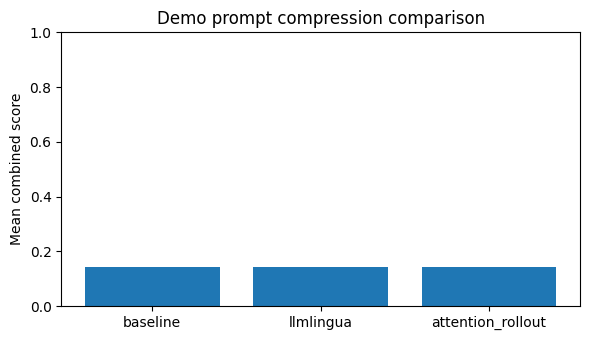


Bootstrap 95% CIs:
baseline_2.0x_single_doc_qa: [0.143, 0.143]
llmlingua_2.0x_single_doc_qa: [0.144, 0.144]
attention_rollout_2.0x_single_doc_qa: [0.144, 0.144]

Significant tests (p < 0.05):
attention_rollout_vs_baseline_2.0x_single_doc_qa: p=1.0000
attention_rollout_vs_llmlingua_2.0x_single_doc_qa: p=1.0000

Survivor method: llmlingua


In [12]:
# Build readable summary table
summary_rows = []
for key, metrics in aggregated.items():
    method, ratio, category = key
    summary_rows.append({
        'method': method,
        'ratio': ratio,
        'category': category,
        'mean_f1': metrics.mean_f1,
        'mean_rouge_l': metrics.mean_rouge_l,
        'mean_combined': metrics.mean_combined,
    })
for row in sorted(summary_rows, key=lambda r: (r['method'], r['ratio'])):
    print(
        f"{row['method']:>20} | {row['ratio']:>4}x | {row['category']:>20} | "
        f"F1={row['mean_f1']:.3f} ROUGE-L={row['mean_rouge_l']:.3f} combined={row['mean_combined']:.3f}"
    )

# Plot combined scores by method
plot_data = defaultdict(list)
for key, metrics in aggregated.items():
    plot_data[key[0]].append(metrics.mean_combined)
methods_in_plot = list(plot_data.keys())
values = [np.mean(plot_data[m]) for m in methods_in_plot]

plt.figure(figsize=(6, 3.5))
plt.bar(methods_in_plot, values)
plt.ylabel('Mean combined score')
plt.title('Demo prompt compression comparison')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Print bootstrap CIs
print("\nBootstrap 95% CIs:")
for key, ci in bootstrap_cis.items():
    print(f"{key}: [{ci['lower']:.3f}, {ci['upper']:.3f}]")

# Print significant tests
print("\nSignificant tests (p < 0.05):")
for test, p_val in significance.items():
    marker = " *" if p_val < 0.05 else ""
    print(f"{test}: p={p_val:.4f}{marker}")

print("\nSurvivor method:", rank_results['survivor'])
